In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

import seaborn as sns

In [ ]:
lfw = fetch_lfw_people(
    min_faces_per_person=70,
    resize=1.0
)

X = lfw.images
y = lfw.target

print("Images Shape:", X.shape)
print("Classes:", len(lfw.target_names))
print(lfw.target_names)

Images Shape: (1288, 125, 94)
Classes: 7
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


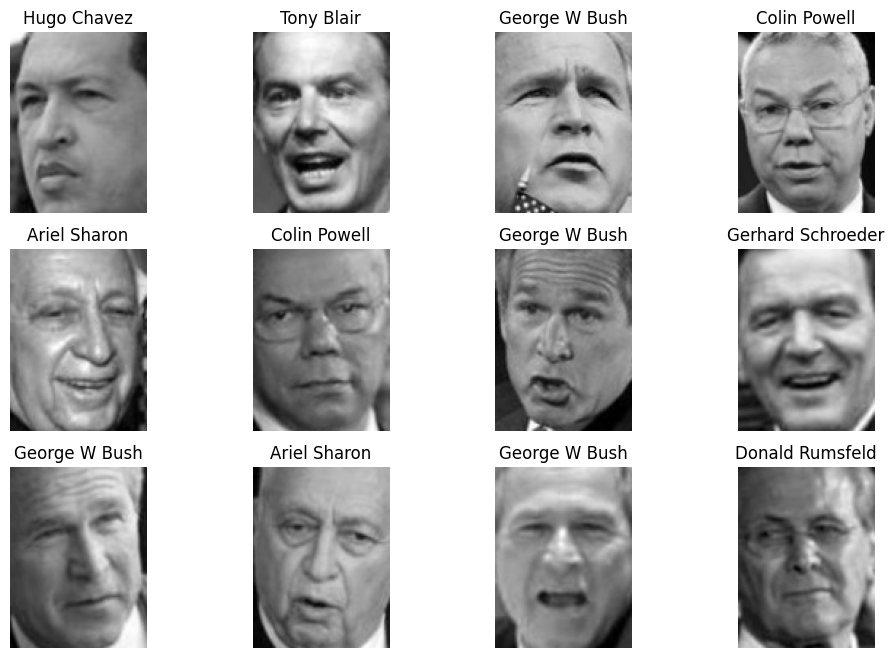

In [ ]:
plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(lfw.target_names[y[i]])
    plt.axis('off')

plt.show()

In [ ]:
print("Min Pixel:", np.min(X))
print("Max Pixel:", np.max(X))

Min Pixel: 0.0
Max Pixel: 1.0


In [ ]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    X.shape[2],
    1
)

y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print(X_train.shape)
print(X_test.shape)

(1030, 125, 94, 1)
(258, 125, 94, 1)


In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=X_train.shape[1:]
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 125, 94, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 62, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 62, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 31, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 21120)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     5,406,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,501,447 (20.99 MB)

 Trainable params: 5,501,447 (20.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.3990 - loss: 1.7550 - val_accuracy: 0.4109 - val_loss: 1.6772
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4107 - loss: 1.7054 - val_accuracy: 0.4109 - val_loss: 1.6336
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4359 - loss: 1.5841 - val_accuracy: 0.4767 - val_loss: 1.3723
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5359 - loss: 1.2271 - val_accuracy: 0.6047 - val_loss: 1.0624
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7078 - loss: 0.8269 - val_accuracy: 0.7636 - val_loss: 0.6887
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7913 - loss: 0.6031 - val_accuracy: 0.7481 - val_loss: 0.6357
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8408 - loss: 0.4522 - val_accuracy: 0.8178 - val_loss: 0.5743
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8835 - loss: 0.3586 - val_accuracy: 0.8450 - 

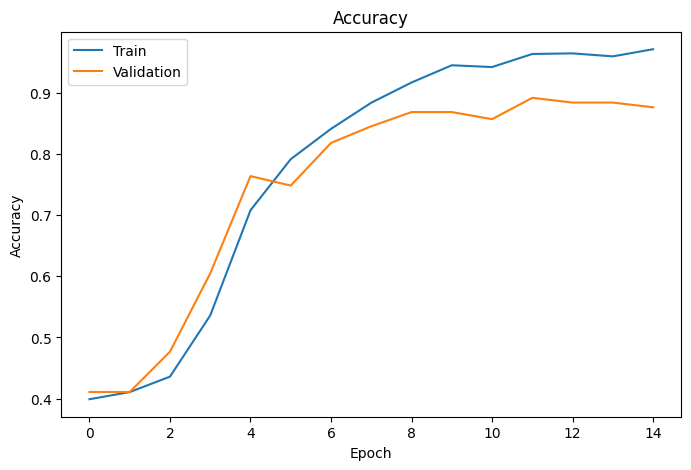

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

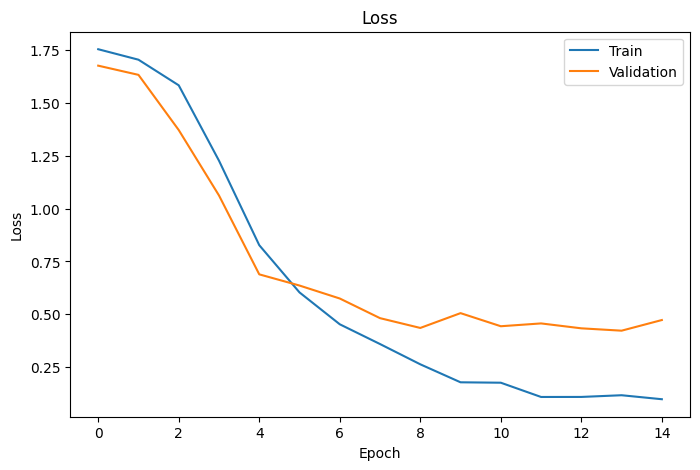

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy =", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8760 - loss: 0.4723 
Test Accuracy = 0.8759689927101135


In [ ]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


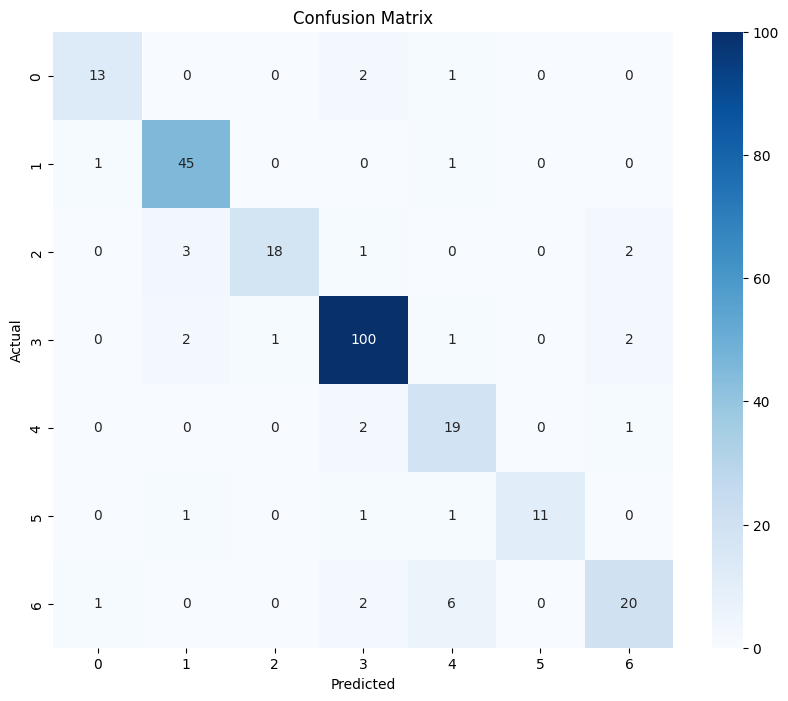

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=lfw.target_names
    )
)

                   precision    recall  f1-score   support

     Ariel Sharon       0.87      0.81      0.84        16
     Colin Powell       0.88      0.96      0.92        47
  Donald Rumsfeld       0.95      0.75      0.84        24
    George W Bush       0.93      0.94      0.93       106
Gerhard Schroeder       0.66      0.86      0.75        22
      Hugo Chavez       1.00      0.79      0.88        14
       Tony Blair       0.80      0.69      0.74        29

         accuracy                           0.88       258
        macro avg       0.87      0.83      0.84       258
     weighted avg       0.88      0.88      0.88       258



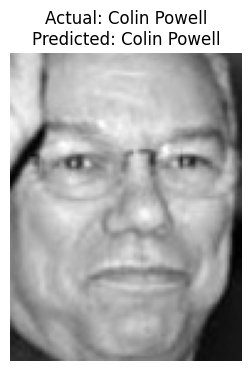

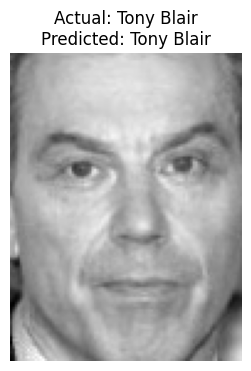

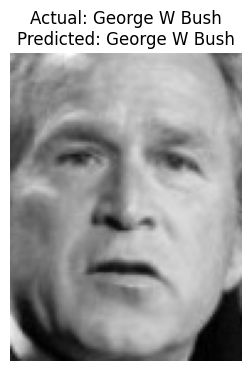

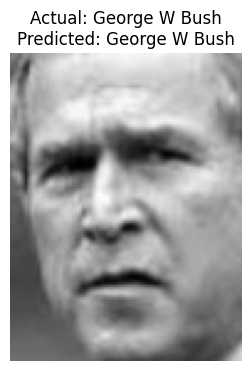

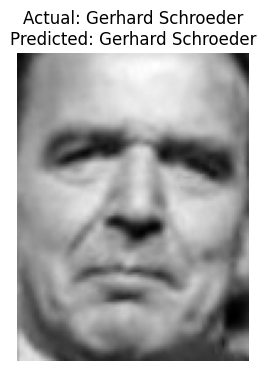

In [ ]:
for i in range(5):

    plt.figure(figsize=(4,4))

    plt.imshow(
        X_test[i].reshape(
            X_test.shape[1],
            X_test.shape[2]
        ),
        cmap='gray'
    )

    actual = lfw.target_names[y_true[i]]
    predicted = lfw.target_names[y_pred[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')
    plt.show()

In [ ]:
model.save(
    "face_recognition_model.keras"
)

print("Model Saved")

Model Saved


In [ ]:
loaded_model = tf.keras.models.load_model(
    "face_recognition_model.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully
